In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sampling import sample_sphere, sample_ball, sample_around_point
from helper import merge_domains_nd, update_neighbors, get_neighbors
from shapes import Sphere, ConvexHull, EgoSphere


VIEW_RANGE = 20
MOVEMENT_RANGE= 5
EPSILON = 0.4999999

In [66]:
def load_ndarray(name: str) -> np.ndarray:
    """Companion loader that reconstructs the array from the saved file."""
    with open(name, "r") as f:
        n     = int(f.readline().strip())
        shape = tuple(int(s) for s in f.readline().strip().split())
        flat  = list(map(float, f.readline().strip().split()))

    return np.array(flat).reshape(shape)

In [68]:
def estimate_gradient(points, values, center_point, center_value=None, trim_bottom=0.20):
    points = np.asarray(points, dtype=float)
    values = np.asarray(values, dtype=float)
    center_point = np.asarray(center_point, dtype=float)

    # Remove bottom X% of values
    if trim_bottom > 0:
        threshold = np.quantile(values, trim_bottom)
        mask = values >= threshold
        points = points[mask]
        values = values[mask]

    A = points - center_point

    if center_value is not None:
        b = values - center_value
        gradient = np.linalg.lstsq(A, b, rcond=None)[0]
    else:
        A_aug = np.hstack([A, np.ones((len(A), 1))])
        result = np.linalg.lstsq(A_aug, values, rcond=None)[0]
        gradient = result[:-1]

    return gradient / np.linalg.norm(gradient)

In [69]:
def dist_to_edge(point, array):
    point = np.asarray(point)
    shape = np.asarray(array.shape)
    
    dist_to_min = point
    dist_to_max = shape - 1 - point
    
    return np.min(np.minimum(dist_to_min, dist_to_max))

In [153]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_heatmap_3d(data_original: np.ndarray, path: np.array, clip_percentile: float = 100, max_alpha: float = 0.8):
    data = data_original.copy()
    data = np.clip(data, 0, np.percentile(data, clip_percentile))
    norm = (data - data.min()) / (data.max() - data.min() + 1e-8)

    n = data.shape
    x, y, z = np.meshgrid(np.arange(n[0]), np.arange(n[1]), np.arange(n[2]))

    v = norm.flatten()

    # only plot voxels above a threshold to remove empty space
    threshold = 0.1
    mask = v > threshold
    
    colors = cm.plasma(v[mask])
    colors[:, 3] = v[mask] * max_alpha  # keep alpha very low so interior shows through

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(
        x.flatten()[mask],
        y.flatten()[mask],
        z.flatten()[mask],
        c=colors, marker="s", s=30, linewidths=0
    )

    mappable = cm.ScalarMappable(
        cmap="plasma",
        norm=plt.Normalize(vmin=data.min(), vmax=data.max())
    )
    fig.colorbar(mappable, ax=ax, fraction=0.03, pad=0.1, label="Heat")
    ax.scatter(*path.T)
    ax.set_title("3D Heatmap")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    plt.tight_layout()
    plt.show()


In [114]:
def ego_centric_wos_mapping(view_range, domain, min_corner, start, goal, distance_field, min_corner_field, dim, n_walks=1000):
    ego_sphere = EgoSphere(view_range, start, goal)

    surrounding = get_neighbors(distance_field, start - min_corner_field)
    radius = float('inf')
    for _, i in surrounding:
        if i < radius:
            radius = i

    domain = WoS_altered_g(ego_sphere, distance_field, min_corner_field, goal, start, radius, n_walks, domain, min_corner)
    sampled_points = []
    sampled_vals = []
    adjusted = start-min_corner
    while len(sampled_vals) < 100:
        samples = get_neighbors(domain, sample_ball(dim, radius, adjusted))
        for coord, heat in samples:
            if heat > 0 and coord[-1]>start[-1]:
                sampled_points.append(coord+min_corner)
                sampled_vals.append(heat)

    next = estimate_gradient(sampled_points, sampled_vals, start, center_value=None)
    next /= next[-1]
    start += next

    return domain, start

def WoS_altered_g(ego_sphere,  distance_field, min_corner_field, goal, start, radius, n_walks, overall_domain, min_corner):
    dim = len(start)
    for walk in range(n_walks):
        first_step = sample_ball(dim, radius, start) 
        wos_walk_altered_g(ego_sphere,  distance_field, min_corner_field, goal, first_step, overall_domain, min_corner, 0)
    return overall_domain

def wos_walk_altered_g(ego_sphere, distance_field, min_corner_field, goal, start, overall_domain, min_corner, curr_rec):
    if curr_rec == 30:
        return 0
    adjusted_start = start-min_corner
    dist_b = dist_to_edge(adjusted_start, overall_domain)
    boundary_hit = True
    dist_o = get_neighbors(distance_field, start-min_corner_field)
    for i in dist_o:
        if i[1] <dist_b:
            dist_b = i[1]
            boundary_hit = False

            
    if dist_b<EPSILON or boundary_hit:
        if boundary_hit:
            dist = np.linalg.norm(start-goal)
            point = (ego_sphere.g(dist)*100000000)
            update_neighbors(overall_domain, adjusted_start, point)
            return point
        else:
            return None
    
    point = None
    while point == None:
        v = sample_sphere(ego_sphere.dim, dist_b, start)
        point = wos_walk_altered_g(ego_sphere, distance_field, min_corner_field, goal, v, overall_domain, min_corner, curr_rec+1)

    update_neighbors(overall_domain, adjusted_start, point)
    return point

In [143]:
def path_mapping(start, goal, distance_field, min_corner_field, dim, n_walks=1000):
    dist_g = np.ceil(np.linalg.norm(start-goal)).astype(int)
    path = [start.copy()]
    heatmaps = []
    domain = np.zeros(shape=[1]*(dim))
    min_corner = start
    time = 20
    while dist_g>1:
        print(start)
        view_range = np.floor(min(VIEW_RANGE, dist_g)).astype(int)
        domain_size = view_range * 2 + 1
        new_min_corner = start - np.array([view_range]*dim)
        domain, min_corner = merge_domains_nd(domain, min_corner, new_min_corner, tuple([domain_size]*dim))

        solved_domain, start = ego_centric_wos_mapping(view_range, domain, min_corner, start, goal, distance_field, min_corner_field, dim, n_walks)
        path.append(start.copy())
        dist_g = np.linalg.norm(start-goal)
        plot_heatmap_3d(solved_domain[:, :, :, np.round(start[-1]).astype(int)], np.array([
 [100, 50, 50],
 [100, 50, 52],
 [100, 54, 50],
 [100, 54, 52],
 [105, 50, 50],
 [105, 50, 52],
 [105, 54, 50],
 [105, 54, 52]]) + np.array([time, 0, 0] - min_corner[:3]))
        time += 1
        heatmaps.append(solved_domain)

    return heatmaps, path


In [144]:
cube_3d = ConvexHull([[450,450,450],[550,550,550],[450,550,550],[450,450,550], [550,450,550],[550,550,450],[550,450,450],[450,550,450]])
slit_2d = [ConvexHull([[0,500],[300,500],[0,550],[300,550]]), ConvexHull([[750,500],[320,500],[750,550],[320,550]])]
box_2d = [ConvexHull([[200,400],[200,700]]), ConvexHull([[300,400],[300,700]]), ConvexHull([[300,700],[200,700]])]
forest = []
line = ConvexHull([[500,500], [600,500]])
offsets = []
for i in range(30):
    tree = line.copy()
    offset = np.array([np.round(np.random.uniform(-450, 450)).astype(int), np.round(np.random.uniform(-450, 450)).astype(int)])
    offsets.append(offset)
    tree.shift_center(offset)
    forest.append(tree)

n_walks = 100000
view_range = 150
epsilon = 1


pinhole = [ConvexHull([[0,0,450],[1000,0,450],[1000,500,450],[0,500,450],[0,0,550],[1000,0,550],[1000,500,550],[0,500,550]]),
           ConvexHull([[0,550,450],[1000,550,450],[1000,1000,450],[0,1000,450],[0,550,550],[1000,550,550],[1000,1000,550],[0,1000,550]]),
           ConvexHull([[0,500,450],[500,500,450],[500,550,450],[0,550,450],[0,500,550],[500,500,550],[500,550,550],[0,550,550]]),
           ConvexHull([[550,500,450],[1000,500,450],[1000,550,450],[550,550,450],[550,500,550],[1000,500,550],[1000,550,550],[550,550,550]])
]

In [155]:
start = np.array([113.0, 52.0, 45.0, 20.0])
goal = np.array([113.0, 52.0, 60.0, 70.0])
dim = len(start)
distance_field = load_ndarray('moving_rectangle')
min_corner_field = np.array([103.0, 52.0, 45.0, 10.0])

[113.  52.  45.  20.]


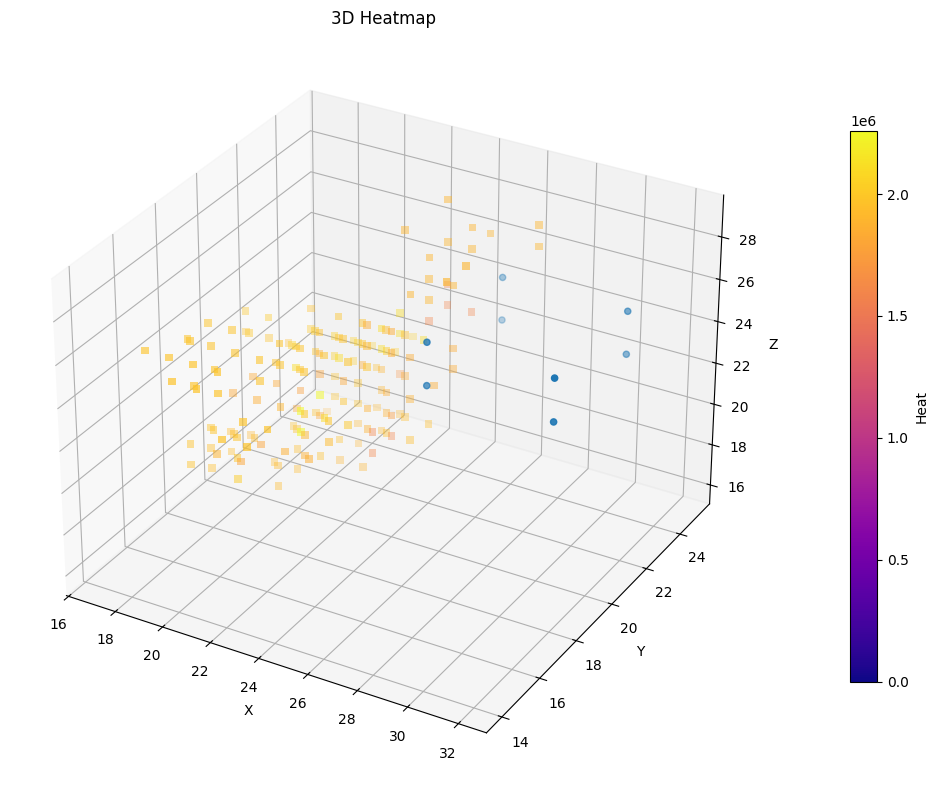

[112.64740143  52.13264603  45.33144873  21.        ]


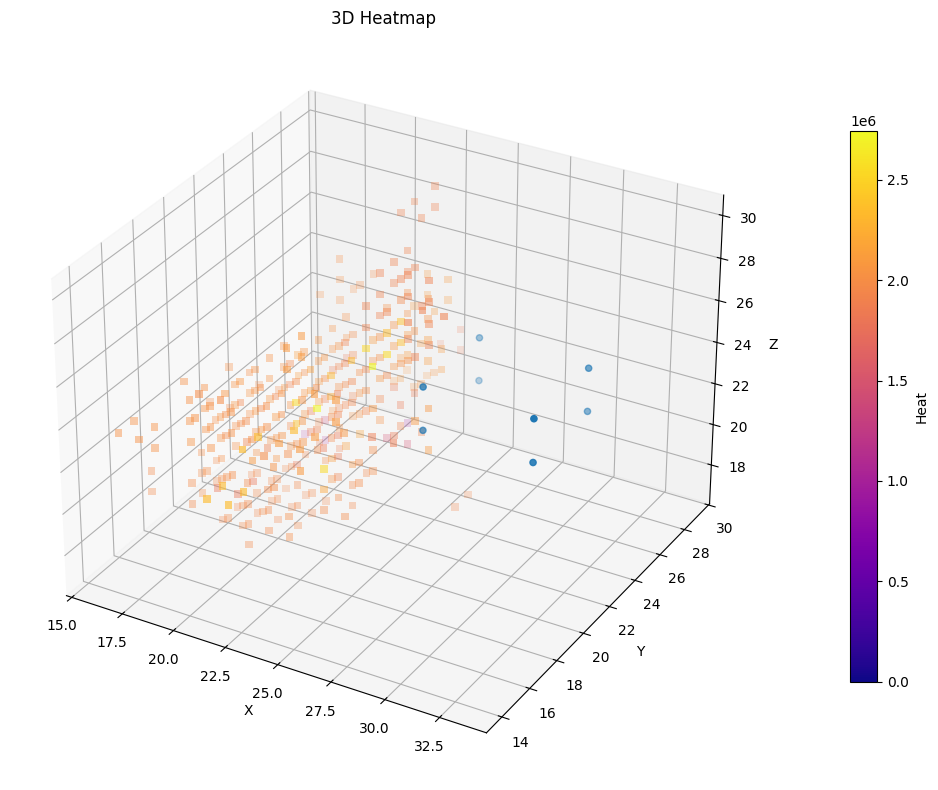

[111.85271565  52.92087624  45.92545844  22.        ]


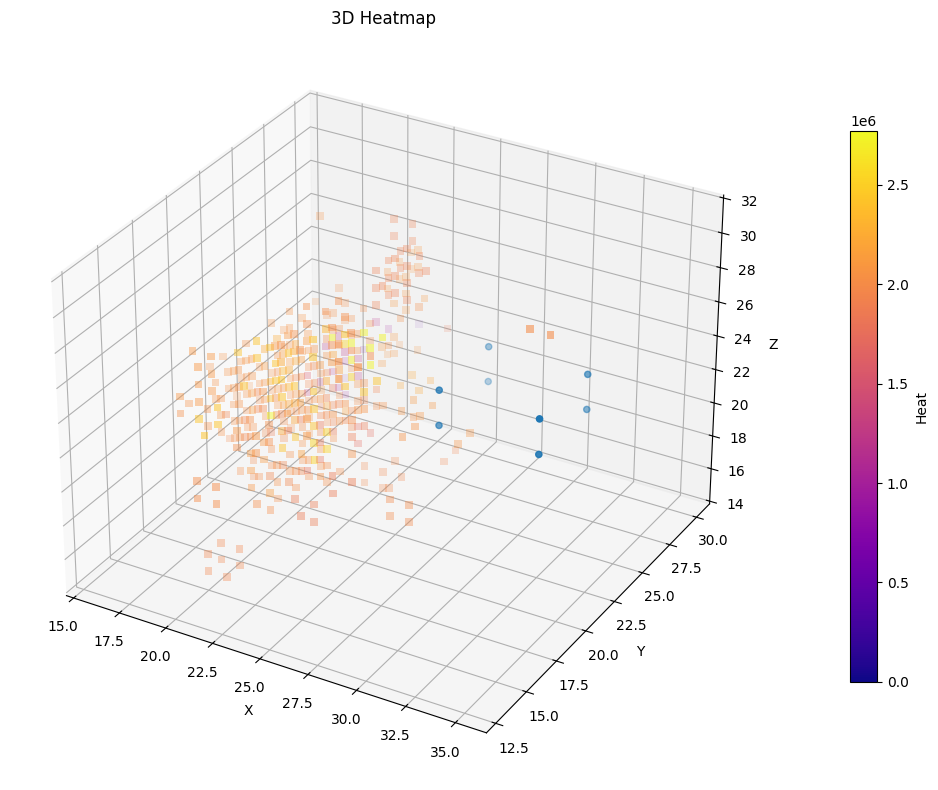

[111.47916537  53.42228147  46.81255318  23.        ]


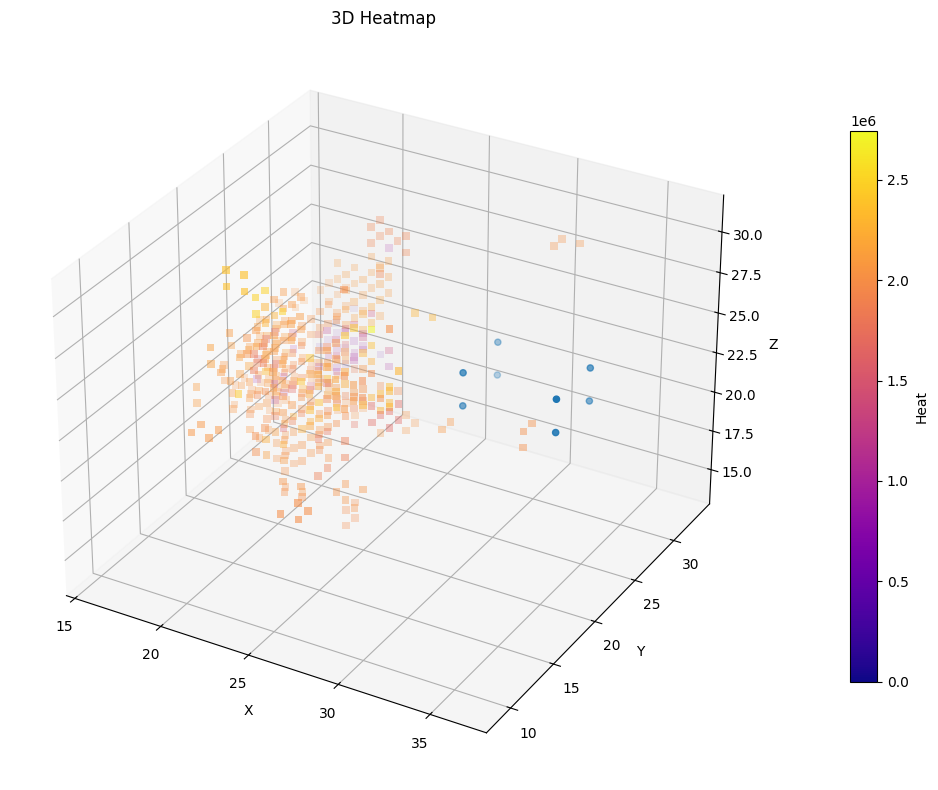

[112.17221623  53.0294926   46.66013045  24.        ]


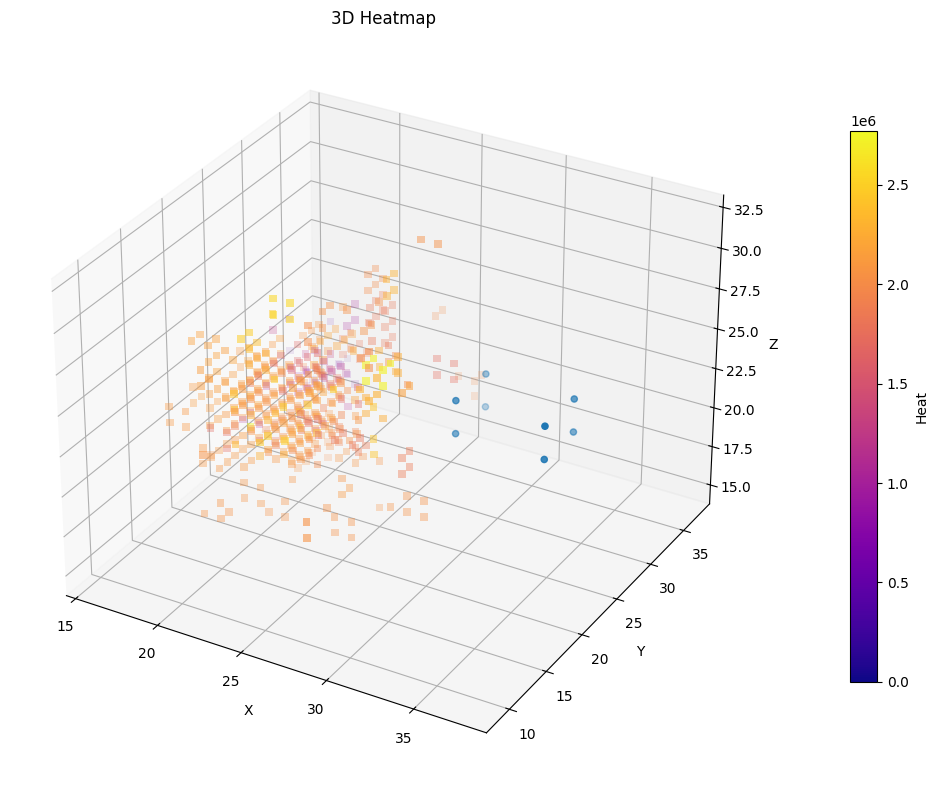

[113.21592833  51.24915643  44.66682609  25.        ]


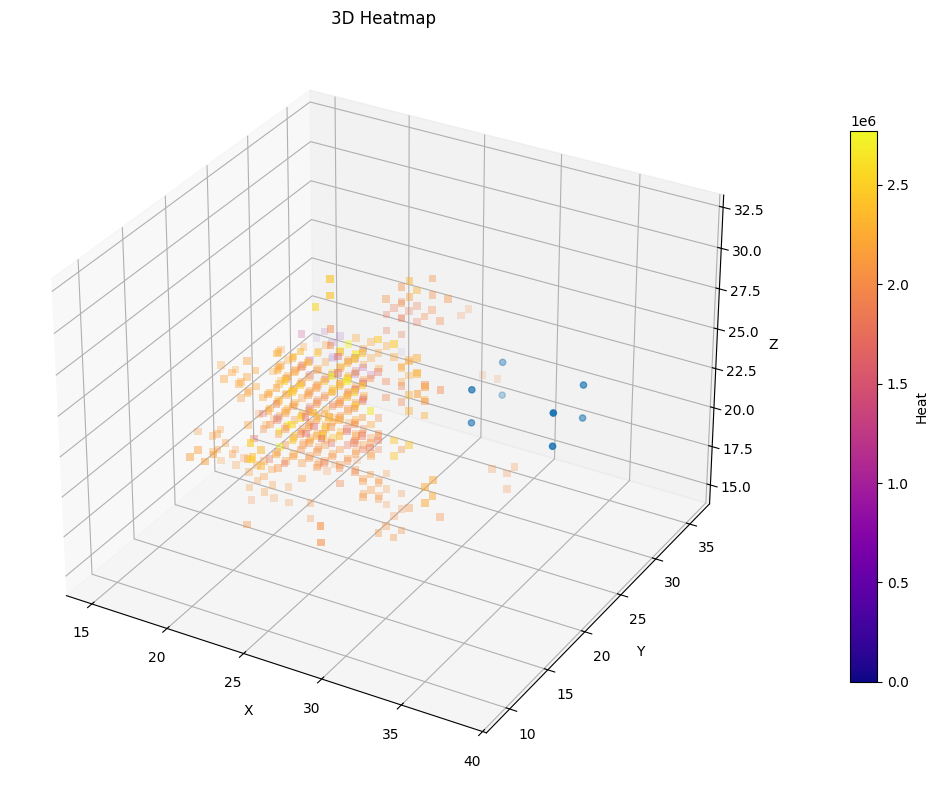

[113.18968515  51.17649925  45.60171236  26.        ]


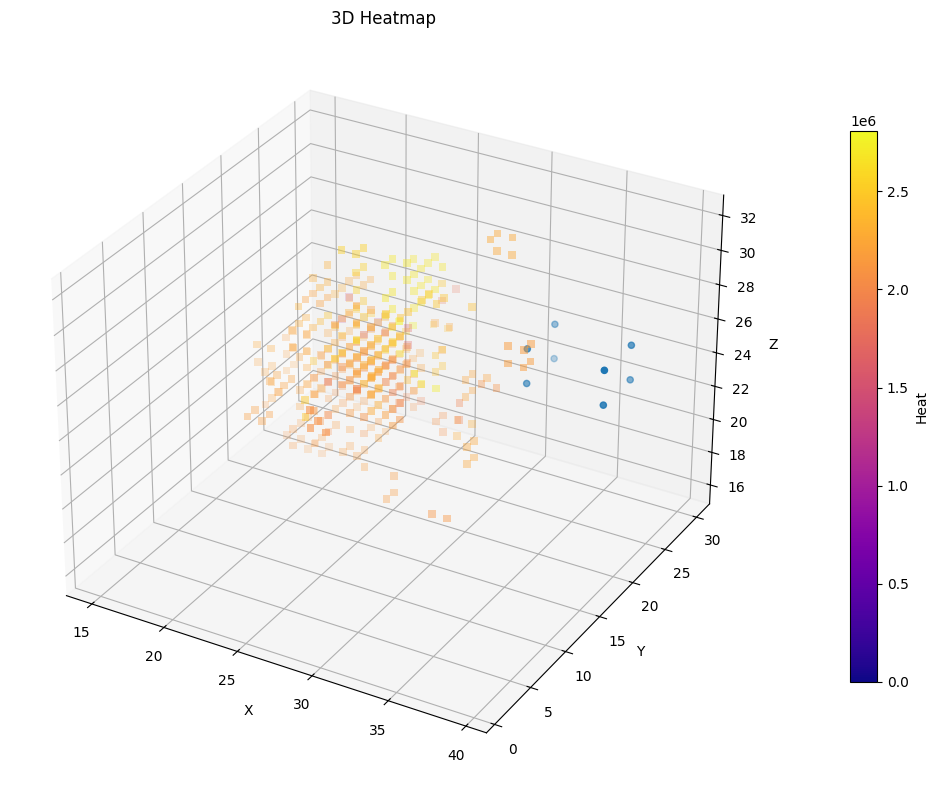

[113.11061838  51.94191399  46.73705803  27.        ]


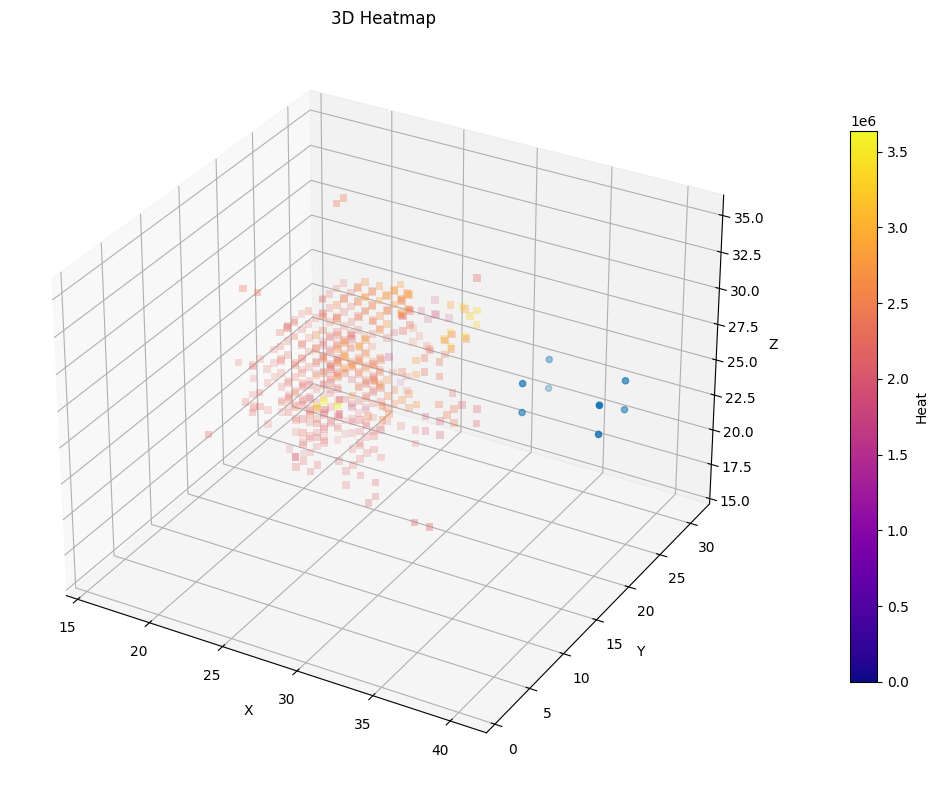

[117.87868506  35.48045938  41.26884001  28.        ]


OverflowError: cannot convert float infinity to integer

In [156]:
heatmaps, paths = path_mapping(start, goal, distance_field, min_corner_field, dim, n_walks=100)

NameError: name 'heatmaps' is not defined

Error in callback <function _draw_all_if_interactive at 0x000001D2FFD86E50> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

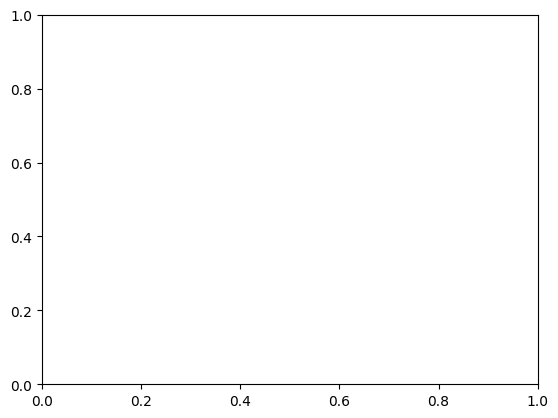

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from tqdm import tqdm

fig, ax = plt.subplots()

im = ax.imshow(heatmaps[0], cmap='inferno', animated=True)
plt.colorbar(im, ax=ax)

line_object = ax.plot([], [], 'r-')[0]
pbar = tqdm(total=len(heatmaps), desc='Rendering')

def update(frame):
    im.set_data(heatmaps[frame])
    ax.set_title(f'Frame {frame + 1} / {len(heatmaps)}')
    path = np.array(paths[frame])
    line_object.set_data(path[:, 1], path[:, 0])
    pbar.update(1)
    return [im, line_object]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(heatmaps),
    interval=500,
    blit=False
)

ani.save('output.gif', writer='pillow', fps=10)
pbar.close()
plt.show()